In [2]:
# from ortools.sat.python import cp_model
from InstanceCVRPTWUI import InstanceCVRPTWUI
import SolutionCVRPTWUI
import distribution_model #build_distribution_model
import distribution_model_2 #build_distribution_model
import distribution_model_old #build_distribution_model
import route_planner_from_distribution as route_planner
from importlib import reload

path = r"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib"
dataset = r"ORTEC-test"
instance_name ="ORTEC_Test_01.txt"
solution_name = instance_name[:-4] + ".sol.txt"

In [2]:
print(path)
print(dataset)
print(solution_name)
print(f"{path}\\{dataset}\\{instance_name}")
print(f"{path}\\{dataset}\\{solution_name}")

C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib
ORTEC-test
ORTEC_Test_01.sol.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_01.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_01.sol.txt


##### write_solution

In [9]:
# path = r"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib"
# dataset = r"ORTEC-test"
# instance_name ="ORTEC_Test_01.txt"
# solution_name = instance_name[:-4] + ".sol.txt"
def write_solution_old(filename=f"{path}\\{dataset}\\{solution_name}", dist={}):
    try:
        fd = open(filename,  mode='w')
    except:
        return (False, 'Could not write to file.')
    # path = r"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib"
    # dataset = r"ORTEC-test"
    # instance_name ="ORTEC_Test_01.txt"
    # solution_name = instance_name[:-4] + ".sol.txt"
    _writeAssignment(fd,"DATASET",dataset)
    _writeAssignment(fd,"NAME",instance_name[:-4])
    fd.write('\n')
    print(f"DATASET = {dataset}")
    #print(f"NAME = {instance_name[:-4]}")
    Days = sorted({d for (d, _) in dist.values()} | {p for (_, p) in dist.values()})
    #print(Days)
    all_rows = []
    for day in Days:
        num_of_trucks = 0
        rows = []
        for req_id in dist.keys():
            if dist[req_id][0] == day:
                rows.append(req_id)
                num_of_trucks += 1
            if dist[req_id][1] == day:
                rows.append(-req_id)
                num_of_trucks += 1
        if not rows:
            continue
        all_rows.append((day, num_of_trucks, rows))
    for (day, num_of_trucks, rows) in all_rows:
        _writeAssignment(fd,"DAY",day)
        #print(f"DAY = {day}\n")
        for truck in range(num_of_trucks):
            fd.write(f"{truck + 1} R 0 {str(rows[truck])} 0\n")
            #print(f"{truck + 1} R 0 {rows[truck]} 0")
        #print(f"NUMBER_OF_VEHICLES = {num_of_trucks}")
        fd.write('\n')
    fd.close()


def _writeAssignment(fd,lhs,rhs):
    fd.write('%s = %s\n' % (lhs,str(rhs)))

In [10]:
def write_solution(filename=f"{path}\\{dataset}\\{solution_name}", 
                   dist={}, 
                   dataset_name="ORTEC-test", 
                   instance_name="ORTEC_Test_01.txt"):
    try:
        fd = open(filename, mode='w')
    except:
        return (False, 'Could not write to file.')

    _writeAssignment(fd, "DATASET", dataset_name)
    _writeAssignment(fd, "NAME", instance_name[:-4])
    fd.write('\n')

    # Extract all relevant days (Delivery days and Pickup days)
    # dist values are (delivery_day, pickup_day, source_id)
    days = sorted({val[0] for val in dist.values()} | {val[1] for val in dist.values()})

    # Days = sorted({d for (d, _, _) in dist.values()} | {p for (_, p, _) in dist.values()})
    print(days)
    # print(Days)
    #                final_assignment[del_req] = (d_day, p_day, best_source)
    for day in days:
        # 1. Identify all events happening today
        deliveries_today = []
        pickups_today = []
        
        for req_id, (d_day, p_day, src_id) in dist.items():
            if d_day == day:
                deliveries_today.append(req_id)
            if p_day == day:
                pickups_today.append(req_id)

        # 2. Build Routes
        # We store the "middle" of the route here. The 0s are added during writing.
        # Format: [[req_id], [-req_id], [-source, req_id], ...]
        truck_routes = []
        processed_pickups = set()

        # A. Handle Deliveries (and their linked sources if any)
        for req_id in deliveries_today:
            _, _, source = dist[req_id]
            
            if source != 0:
                # Direct Transfer: Depot -> Pickup Source -> Deliver Request -> Depot
                # Note: 'source' is the ID of the request we are picking up tools FROM
                truck_routes.append([-source, req_id])
                processed_pickups.add(source)
            else:
                # Standard Delivery: Depot -> Deliver Request -> Depot
                truck_routes.append([req_id])

        # B. Handle Remaining Pickups (those not used as sources today)
        for req_id in pickups_today:
            if req_id not in processed_pickups:
                # Standard Pickup: Depot -> Pickup Request -> Depot
                truck_routes.append([-req_id])
        # print(truck_routes)
        # 3. Write to File
        if not truck_routes:
            continue

        _writeAssignment(fd, "DAY", day)
        _writeAssignment(fd, "NUMBER_OF_VEHICLES", len(truck_routes))
        
        for i, route_stops in enumerate(truck_routes):
            # print(f"{i+1, route_stops}")
            # formatting: "1 R 0 node1 node2 0"
            stops_str = " ".join(str(x) for x in route_stops)
            fd.write(f"{i + 1} R 0 {stops_str} 0\n")
        
        fd.write('\n')

    fd.close()
    print(f"Solution written to {filename}")
    return (True, "Success")

In [11]:
def write_solution_from_routes(filename=f"{path}\\{dataset}\\{solution_name}", 
                               routes_by_day={}, 
                               dataset="ORTEC-test", 
                               instance_name="ORTEC_Test_01.txt"):
    """
    routes_by_day: dict day -> list of routes
      each route: list of signed ints [r1, -r2, r3, ...] (positive = delivery, negative = pickup)
      depot is implicit at start & end
    dataset, instance_name - strings used in header

    returns (True, "success"") on success
    """
    try:
        fd = open(filename, mode='w')
    except Exception as e:
        return (False, f"Could not open file for writing: {e}")

    def _writeAssignment(lhs, rhs):
        fd.write(f"{lhs} = {rhs}\n")

    _writeAssignment("DATASET", dataset)
    _writeAssignment("NAME", instance_name)
    fd.write("\n")

    # Build list of (day, num_vehicles, rows) sorted by day
    all_days = sorted(routes_by_day.keys())
    for day in all_days:
        routes = routes_by_day[day]
        if not routes:
            continue
        _writeAssignment("DAY", day)
        num_vehicles = len(routes)
        _writeAssignment("NUMBER_OF_VEHICLES", num_vehicles)
        # Write each route as a vehicle line
        for veh_idx, route in enumerate(routes):
            # route is list of ints; we must write them space separated between the "R 0" and final "0"
            row_tokens = ' '.join(str(int(x)) for x in route)
            fd.write(f"{veh_idx+1} R {row_tokens}\n")
        fd.write("\n")
    fd.close()
    return (True, "Success")


##### Basic

In [ ]:
reload(distribution_model)
reload(distribution_model_old)
reload(route_planner)


path = r"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib"
dataset = r"ORTEC-test"
instance_name ="ORTEC_Test_01.txt"
solution_name = instance_name[:-4] + ".sol.txt"

time_limit = 600
instance = InstanceCVRPTWUI(f"{path}\\{dataset}\\{instance_name}", "txt", False)
# instance = InstanceCVRPTWUI(r"C:\Users\DMS\Desktop\verolog2017_tools_distrib\ParticipantsSuite\input\testInstance.txt", "txt", False)
if instance.isValid():
    dist = distribution_model_old.build_distribution_model(instance, max_time=time_limit, verbose=True)
    print(dist)

if dist:
    write_solution_old(filename=f"{path}\\{dataset}\\{solution_name}",dist=dist)
# 1: (2, 3, 58)

In [ ]:
write_solution_old(dist=dist)

###### early

In [13]:
# from ortools.sat.python import cp_model
from InstanceCVRPTWUI import InstanceCVRPTWUI
# from SolutionCVRPTWUI import DoWork
import distribution_model #build_distribution_model
import distribution_model_old #build_distribution_model
import route_planner_from_distribution as route_planner
from importlib import reload

path = r"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib"
dataset = r"ORTEC-test"
instance_name ="ORTEC_Test_01.txt"
solution_name = instance_name[:-4] + ".sol.txt"

print(path)
print(dataset)
print(solution_name)
print(f"{path}\\{dataset}\\{instance_name}")
print(f"{path}\\{dataset}\\{solution_name}")

C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib
ORTEC-test
ORTEC_Test_01.sol.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_01.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_01.sol.txt


In [25]:
reload(distribution_model)
reload(distribution_model_old)
reload(route_planner)


path = r"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib"
dataset = r"ORTEC-early"
instance_name ="VeRoLog_r500d15_1.txt"
solution_name = instance_name[:-4] + ".sol.txt"

time_limit = 600
instance = InstanceCVRPTWUI(f"{path}\\{dataset}\\{instance_name}", "txt", False)
# instance = InstanceCVRPTWUI(r"C:\Users\DMS\Desktop\verolog2017_tools_distrib\ParticipantsSuite\input\testInstance.txt", "txt", False)
if instance.isValid():
    dist = distribution_model_old.build_distribution_model(instance, max_time=time_limit, verbose=True)
    print(dist)

if dist:
    write_solution_old(filename=f"{path}\\{dataset}\\{solution_name}",dist=dist)
# 1: (2, 3, 58)

4
4 2
Feasible distribution found.
{1: (11, 12), 2: (10, 13), 3: (1, 3), 4: (13, 14), 5: (10, 11), 6: (6, 9), 7: (2, 3), 8: (5, 7), 9: (5, 8), 10: (7, 8), 11: (5, 8), 12: (6, 8), 13: (1, 2), 14: (4, 7), 15: (12, 15), 16: (11, 12), 17: (1, 3), 18: (2, 3), 19: (12, 14), 20: (4, 7), 21: (11, 14), 22: (4, 6), 23: (3, 5), 24: (5, 6), 25: (11, 13), 26: (6, 9), 27: (4, 5), 28: (3, 5), 29: (13, 14), 30: (6, 9), 31: (7, 8), 32: (14, 15), 33: (11, 13), 34: (13, 14), 35: (4, 7), 36: (8, 10), 37: (7, 10), 38: (1, 3), 39: (2, 4), 40: (6, 9), 41: (4, 6), 42: (11, 14), 43: (4, 6), 44: (6, 7), 45: (11, 13), 46: (7, 10), 47: (12, 15), 48: (3, 5), 49: (4, 5), 50: (11, 13), 51: (1, 3), 52: (14, 15), 53: (13, 14), 54: (10, 13), 55: (7, 8), 56: (12, 14), 57: (3, 5), 58: (9, 11), 59: (10, 11), 60: (7, 8), 61: (3, 6), 62: (1, 3), 63: (11, 14), 64: (11, 12), 65: (4, 6), 66: (3, 4), 67: (3, 4), 68: (12, 14), 69: (8, 9), 70: (1, 3), 71: (3, 4), 72: (2, 4), 73: (9, 11), 74: (1, 2), 75: (6, 9), 76: (6, 9), 77: (9

In [ ]:
filename=f"{path}\\{dataset}"


SyntaxError: unterminated string literal (detected at line 2) (2040323809.py, line 2)

##### Basic+

In [4]:
import multiprocessing
import os
os.cpu_count(), multiprocessing.cpu_count()

(14, 14)

In [85]:
reload(distribution_model)
reload(distribution_model_2)
reload(distribution_model_old)
reload(route_planner)


path = r"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib"
dataset = r"ORTEC-Test"
instance_name ="ORTEC_Test_03.txt"
solution_name = instance_name[:-4] + "_2.sol.txt"

time_limit = 600
instance = InstanceCVRPTWUI(f"{path}\\{dataset}\\{instance_name}", "txt", False)
# instance = InstanceCVRPTWUI(r"C:\Users\DMS\Desktop\verolog2017_tools_distrib\ParticipantsSuite\input\testInstance.txt", "txt", False)
print(instance.isValid())
if instance.isValid():
    dist = distribution_model_2.build_distribution_model(instance, max_time=time_limit, verbose=True)
    print(dist)
    assignment, routes_by_day, total_distance = dist
    print()
    print(assignment)
    print(routes_by_day)
    print(total_distance)

if dist:
    if False:
        write_solution(dist=assignment, 
                       filename = f"{path}\\{dataset}\\{solution_name}",
                       dataset_name = dataset,
                       instance_name = instance_name)
        write_solution_from_routes(filename=f"{path}\\{dataset}\\{solution_name}",
                                   routes_by_day=routes_by_day, 
                                   dataset=dataset, 
                                   instance_name=instance_name)
# 1: (2, 3, 58)

# then in terminal:
#     python3 .\SolutionCVRPTWUI.py -s ..\ORTEC-test\ORTEC_Test_02.sol.txt -i ..\ORTEC-test\ORTEC_Test_02.txt
# here .\SolutionCVRPTWUI.py is where the verifier is at and -s is soluton file place and -i is instance

True
  > Emergency Delivery of 2 to node 32
({1: (2, 3, 0), 2: (11, 14, 0), 3: (3, 5, 0), 4: (13, 14, 0), 5: (1, 4, 0), 6: (9, 12, 0), 7: (1, 3, 0), 8: (3, 6, 0), 9: (12, 15, 0), 10: (6, 8, 0), 11: (8, 11, 0), 12: (14, 15, 0), 13: (10, 13, 0), 14: (7, 10, 0), 15: (12, 13, 0), 16: (9, 12, 0), 17: (2, 4, 0), 18: (9, 10, 0), 19: (2, 3, 0), 20: (12, 15, 0), 21: (2, 5, 0), 22: (12, 14, 0), 23: (13, 14, 0), 24: (1, 4, 0), 25: (11, 14, 0), 26: (4, 6, 0), 27: (4, 7, 0), 28: (10, 12, 0), 29: (11, 13, 0), 30: (4, 5, 0), 31: (1, 3, 0), 32: (14, 15, 0), 33: (13, 14, 0), 34: (12, 13, 0), 35: (1, 4, 0), 36: (12, 15, 0), 37: (2, 5, 0), 38: (3, 5, 0), 39: (13, 14, 0), 40: (1, 2, 0), 41: (2, 5, 0), 42: (5, 6, 0), 43: (10, 13, 0), 44: (1, 4, 0), 45: (3, 5, 0), 46: (3, 4, 0), 47: (2, 5, 0), 48: (2, 5, 0), 49: (1, 2, 0), 50: (12, 14, 0), 51: (1, 2, 0), 52: (11, 13, 0), 53: (11, 13, 0), 54: (1, 2, 0), 55: (1, 3, 0), 56: (14, 15, 0), 57: (3, 4, 0), 58: (13, 14, 0), 59: (1, 2, 0), 60: (12, 14, 0), 61: (12, 1

In [3]:
path = r"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib"
dataset = r"ORTEC-Test"
instance_name ="ORTEC_Test_01.txt"
solution_name = instance_name[:-4] + ".sol.txt"

In [6]:
def DoWork(args):
    instance = args.instance
    if not instance:
        if args.solution.endswith('.sol.xml'):
            instance = args.solution[:-7] + 'xml'
            print('No instance file specified, trying: %s' % instance)
        elif args.solution.endswith('.sol.txt'):
            instance = args.solution[:-7] + 'txt'
            print('No instance file specified, trying: %s ' % instance)
        else:
            print('No instance file specified and unable to determine one based on the solution file')
            return - 10**20
    
    Instance = InstanceCVRPTWUI(instance,args.itype)
    if not Instance.isValid():
        print('File %s is an invalid CVRPTWUI instance file\nIt contains the following errors:' % instance)
        print( '\t' + '\n\t'.join(Instance.errorReport) )
        return - 10**20
    Solution = SolutionCVRPTWUI.SolutionCVRPTWUI(args.solution,Instance,args.type,args.continueOnError)   
    if Solution.isValid():
        print('Solution %s is a valid CVRPTWUI solution' % args.solution)
        if not args.skipExtraDataCheck:
            res = Solution.areGivenValuesValid()
            if res[0]:
                print('The given solution information is correct')
            else:
                print(res[1])
        print('\t' + '\n\t'.join(str(Solution.calcCost).split('\n')))
        if args.outputFile:
            Solution.writeSolution(args.outputFile,args.writeExtra)
        if len(Solution.warningReport) > 0:
            print('There were warnings:')
            print( '\t' + '\n\t'.join(Solution.warningReport) )
        return Solution.calcCost.Cost
    else:
        print('File %s is an invalid CVRPTWUI solution file\nIt contains the following errors:' % args.solution)
        print( '\t' + '\n\t'.join(Solution.errorReport) )
        if len(Solution.warningReport) > 0:
            print('There were also warnings:')
            print( '\t' + '\n\t'.join(Solution.warningReport) )
        return - 10**30


In [3]:
class argss():
    def __init__(self, solution=None, instance=None,  
                sol_type="txt", itype="txt", 
                continueOnError=False, outputFile=None,
                writeExtra=False,
                skipExtraDataCheck=False
                ):
        self.solution=solution
        self.instance=instance
        self.type=sol_type 
        self.itype=itype
        self.continueOnError=continueOnError
        self.outputFile=outputFile
        self.writeExtra=writeExtra
        self.skipExtraDataCheck=skipExtraDataCheck
        if writeExtra and not outputFile:
            raise ValueError("asaadsa")
        
    def __repr__(self):
        return f" solution path = {self.solution} \n instance path = {self.instance} \n sol_type = {self.type} \n i_type = {self.itype} \n continueOnError = {self.continueOnError} \n outputFile = {self.outputFile} \n writeExtra = {self.writeExtra} \n skipExtraDataCheck = {self.skipExtraDataCheck}\n "

In [31]:
from pathlib import Path

In [60]:
early = [f.name for f in Path(f"{path}\\ORTEC-early").iterdir() if f.is_file()]
hidden = [f.name for f in Path(f"{path}\\ORTEC-hidden").iterdir() if f.is_file()]
late = [f.name for f in Path(f"{path}\\ORTEC-late").iterdir() if f.is_file()]
test = [f.name for f in Path(f"{path}\\ORTEC-test").iterdir() if f.is_file()]
#early, hidden, late, test

In [87]:
path = f"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\\ORTEC-Test"

instance_name ="ORTEC_Test_03.txt"
solution_name = instance_name[:-4] + "_2.sol.txt"
solution_path = f"{path}\\{solution_name}"
instance_path = f"{path}\\{instance_name}"

args = argss(solution=solution_path,
        instance=instance_path)
cost = DoWork(args)

Solution C:\Users\DMS\Desktop\verolog2017_tools_distrib\ORTEC-Test\ORTEC_Test_03_2.sol.txt is a valid CVRPTWUI solution
The given solution information is correct
	Max number of vehicles: 50
	Number of vehicle days: 344
	Distance: 3822332
	Cost: 38552964
	Tool count: [69, 299, 71]


In [43]:
old_all_instances = dict()

for folder in [f.name for f in Path(f"{path}\\old").iterdir()]:
    old_all_instances[folder] = [f.name for f in Path(f"{path}\\old\\{folder}").iterdir() if f.is_file()]

In [18]:
import route_optimiser


In [32]:
reload(distribution_model_2)
reload(distribution_model)
reload(distribution_model_old)
reload(route_planner)

path = r"C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib"
all_costs = {"early":[], "hidden":[], "late":[], "test":[]}
all_costs_named = {"early":{}, "hidden":{}, "late":{}, "test":{}}
old_all_costs_named = {"early":{}, "hidden":{}, "late":{}, "test":{}}


for type_instance in ["early", "hidden", "late", "test"]:
    all_instances = [f.name for f in Path(f"{path}\\ORTEC-{type_instance}").iterdir() if f.is_file()]
    solved_all_instances = [f"{f.name[:-8]}.txt" for f in Path(f"{path}\\ORTEC-{type_instance}\\new").iterdir() if f.is_file()]
    unsolved_all_instances = list(set(all_instances)-set(solved_all_instances))
    print(unsolved_all_instances)
    
    for file_instance_name in all_instances:
        print(file_instance_name)
        time_limit = 1000
        instance_path = f"{path}\\ORTEC-{type_instance}\\{file_instance_name}"
        solution_path = f"{path}\\ORTEC-{type_instance}\\new\\" + file_instance_name[:-4] + ".sol.txt"
        full_sol_path = f"{path}\\ORTEC-{type_instance}\\full\\" + file_instance_name[:-4] + ".sol.txt"

        instance = InstanceCVRPTWUI(instance_path, "txt", False)
        dataset = instance.Dataset
        name = instance.Name
        is_valid = all_costs_pd[type_instance][name]>0  #dataframe of costs,negative means bad
        if not is_valid:continue

        print(instance_path)
        print(solution_path)
        if name is None or dataset is None:
            print(f"Something wrong with instance {file_instance_name}")
            continue
        if instance.isValid():
            # dist = distribution_model_2.build_distribution_model(instance, max_time=time_limit, verbose=True)
            print()
        if dist:
            assignment, routes_by_day, total_distance = dist
            if False:
                write_solution_from_routes(filename=solution_path,
                                        routes_by_day=routes_by_day, 
                                        dataset=dataset, 
                                        instance_name=name)
        else:
            print(f"Instance {name} {instance} has no solution")
        args = argss(solution=solution_path,
                    instance=instance_path,
                    outputFile=full_sol_path,
                    writeExtra=True)
        cost = DoWork(args) 
        # cost = cost*100000 if file_instance_name in unsolved_all_instances and cost is not None else cost
        # all_costs[type_instance].append(cost)
        # all_costs_named[type_instance][name] = cost
        print()
        print()

['VeRoLog_r1000d30_1.txt', 'VeRoLog_r100d10_2.txt', 'VeRoLog_r100d5_4.txt']
VeRoLog_r1000d25_1.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-early\VeRoLog_r1000d25_1.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-early\new\VeRoLog_r1000d25_1.sol.txt

Solution C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-early\new\VeRoLog_r1000d25_1.sol.txt is a valid CVRPTWUI solution
The given solution information is correct
	Max number of vehicles: 42
	Number of vehicle days: 404
	Distance: 4835205
	Cost: 9889843205
	Tool count: [121, 125]
Solution file written to C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-early\full\VeRoLog_r1000d25_1.sol.txt


VeRoLog_r1000d25_2.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-early\VeRoLog_r1000d25_2.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-early\new\VeRoLog_r1000d25_2.sol.txt

Solution C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-early\new\VeRoLog_r1000d25_2.sol.txt

In [68]:
# old_all_costs_named = {"early":{}, "hidden":{}, "late":{}, "test":{}}

        
for type_instance in [ "test"]:
    all_instances = [f.name for f in Path(f"{path}\\old\\{type_instance}").iterdir() if f.is_file()]
    
    for file_instance_name in all_instances:
        print(file_instance_name)
        time_limit = 1000
        instance_path = f"{path}\\ORTEC-{type_instance}\\ORTEC_T{file_instance_name[1:-13]}.txt"
        solution_path = f"{path}\\old\\{type_instance}\\" + file_instance_name[:-4] + ".txt"
        print(instance_path)
        print(solution_path)
        
        #instance = InstanceCVRPTWUI(instance_path, "txt", False)
        dataset = "ORTEC-test"
        name = f"ORTEC_T{file_instance_name[1:-13]}.txt"
        print(name)
        # old_all_instances
        args = argss(solution=solution_path,
                    instance=instance_path,
                    #outputFile=full_sol_path,
                    #writeExtra=True
                    )
        cost = DoWork(args) 
        cost = cost*100000 if file_instance_name in unsolved_all_instances and cost is not None else cost
        old_all_costs_named[type_instance][name] = cost

        


test_02_full.sol.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_02.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\old\test\test_02_full.sol.txt
ORTEC_Test_02.txt
Solution C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\old\test\test_02_full.sol.txt is a valid CVRPTWUI solution
The given solution information is correct
	Max number of vehicles: 122
	Number of vehicle days: 443
	Distance: 2860924
	Cost: 11276186
	Tool count: [121, 55, 84, 62, 77]
test_03_full.sol.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_03.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\old\test\test_03_full.sol.txt
ORTEC_Test_03.txt
File C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\old\test\test_03_full.sol.txt is an invalid CVRPTWUI solution file
It contains the following errors:
	NUMBER_OF_VEHICLES (None) is not an integer.
test_05_full.sol.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_05.txt
C:\\Use

In [27]:
all_costs_named

{'early': {'tools over vehicles over vehicle days over distance with 1000 requests over 25 days': 9889843205,
  'tools over vehicle days over vehicles over distance with 1000 requests over 25 days': 10595892704,
  'vehicles over tools over vehicle days over distance with 1000 requests over 25 days': 718589297,
  'vehicle days over tools over vehicles over distance with 1000 requests over 25 days': 17312301330,
  'tools over distance over vehicle days over vehicles with 1000 requests over 25 days': 539728418040,
  'tools over vehicles over vehicle days over distance with 1000 requests over 30 days': -100000000000000000000000000000000000,
  'tools over vehicle days over vehicles over distance with 1000 requests over 30 days': 8220824426,
  'vehicles over tools over vehicle days over distance with 1000 requests over 30 days': 746011456,
  'vehicle days over tools over vehicles over distance with 1000 requests over 30 days': 15174939552,
  'tools over distance over vehicle days over vehicl

In [55]:
import numpy as np
import pandas as pd

#all_costs_pd = pd.DataFrame(all_costs_named)
old_all_costs_pd = pd.DataFrame(old_all_costs_named)
old_all_costs_pd

,early,hidden,late,test
tools over vehicles over vehicle days over distance with 1000 requests over 25 days,1.216923e+10,4.146091e+09,8.655482e+09,NaN
tools over vehicle days over vehicles over distance with 1000 requests over 25 days,1.165518e+10,1.109500e+10,8.565173e+09,NaN
vehicles over tools over vehicle days over distance with 1000 requests over 25 days,2.956528e+09,NaN,4.166130e+09,NaN
vehicle days over tools over vehicles over distance with 1000 requests over 25 days,1.000816e+11,1.000894e+11,2.015564e+10,NaN
tools over distance over vehicle days over vehicles with 1000 requests over 25 days,1.482574e+12,4.171565e+12,3.012396e+12,NaN
tools over vehicles over vehicle days over distance with 1000 requests over 30 days,9.179037e+09,NaN,NaN,NaN
tools over vehicle days over vehicles over distance with 1000 requests over 30 days,1.035556e+10,NaN,NaN,NaN
vehicles over tools over vehicle days over distance with 1000 requests over 30 days,2.653904e+09,NaN,NaN,NaN
vehicle days over tools over vehicles over distance with 1000 requests over 30 days,6.010433e+10,NaN,NaN,NaN
tools over distance over vehicle days over vehicles with 1000 requests over 30 days,1.516303e+12,NaN,NaN,NaN


In [93]:
means_of_old = old_all_costs_pd.where(old_all_costs_pd>0).mean()
means_of_old

early     2.231675e+11
hidden    1.124011e+12
late      1.560578e+12
test               NaN
dtype: float64

In [29]:
means_of_new = all_costs_pd.where( all_costs_pd>0 ).mean(axis=0)

early          115709179485.0
hidden    400403997571.258057
late           583585312114.0
test             1655244836.1
dtype: object

In [73]:
import matplotlib.pyplot as plt
%matplotlib inline
reload(pd)

<module 'pandas' from 'C:\\Users\\DMS\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\pandas\\__init__.py'>

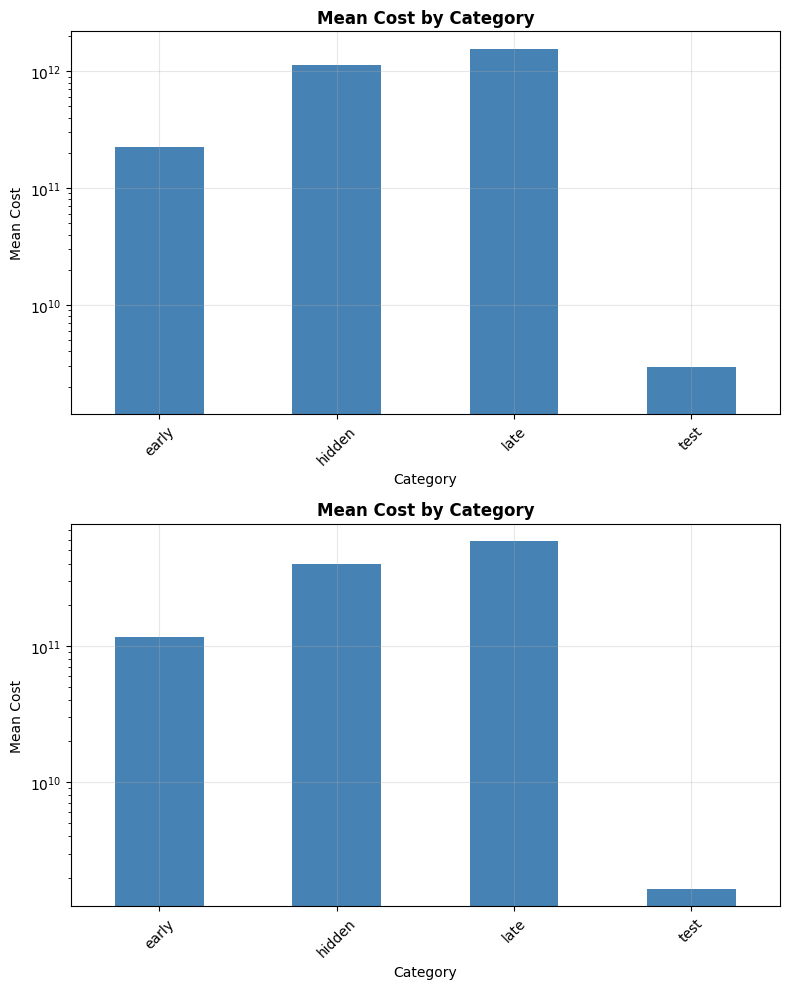

In [91]:

fig, axes = plt.subplots(2, figsize=(8, 10))

ax = axes[0]
means_of_old.plot(kind='bar', ax=ax, color='steelblue')
means_of_new.plot(kind='bar', ax=ax, color='steelblue')

ax.set_title('Mean Cost by Category', fontsize=12, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Mean Cost')
ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)


ax.grid(alpha=0.3)
ax = axes[1]
means_of_new.plot(kind='bar', ax=ax, color='steelblue')

ax.set_title('Mean Cost by Category', fontsize=12, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Mean Cost')
ax.tick_params(axis='x', rotation=45)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)


ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [62]:
pd.DataFrame([means_of_old,means_of_new])

,early,hidden,late,test
0,2.231675e+11,1.124011e+12,1.560578e+12,2.952685e+09
1,1.157092e+11,4.004040e+11,5.835853e+11,1.655245e+09


In [25]:
reload(route_optimiser)

type_instance="test"
file_instance_name="ORTEC_Test_01.txt"
instance_path = f"{path}\\ORTEC-{type_instance}\\{file_instance_name}"
solution_path = f"{path}\\ORTEC-{type_instance}\\new2\\"  + file_instance_name[:-4] + "_2.sol.txt"
full_sol_path = f"{path}\\ORTEC-{type_instance}\\full2\\" + file_instance_name[:-4] + "_2.sol.txt"

print(instance_path)
print(solution_path)
instance = InstanceCVRPTWUI(instance_path, "txt", False)
dataset = instance.Dataset
name = instance.Name

time_limit=600

if name is None or dataset is None:
    print(f"Something wrong with instance {file_instance_name}")

if instance.isValid():
    dist = distribution_model_2.build_distribution_model(instance, max_time=time_limit, verbose=True)
    print()
if dist:
    assignment, routes_by_day, total_distance = dist
    args = argss(solution=solution_path,
                instance=instance_path,
                #outputFile=full_sol_path,
                #writeExtra=True
                )
    cost = DoWork(args) 
    print(cost)

    #routes_by_day = route_optimiser.improve_routes(instance, routes_by_day)


    if False:
        print()
        write_solution_from_routes(filename=solution_path,
                                routes_by_day=routes_by_day, 
                                dataset=dataset, 
                                instance_name=name)
else:
    print(f"Instance {name} {instance} has no solution")
if False:
    print()
args = argss(solution=solution_path,
            instance=instance_path,
            outputFile=full_sol_path,
            writeExtra=True
            )
cost = DoWork(args) 


C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_01.txt
C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_01.sol.txt
  > Emergency Delivery of 2 to node 140

Solution C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_01.sol.txt is a valid CVRPTWUI solution
The given solution information is correct
	Max number of vehicles: 28
	Number of vehicle days: 65
	Distance: 1187219
	Cost: 5253999
	Tool count: [275, 131]
5253999
Solution C:\\Users\\DMS\\Desktop\\verolog2017_tools_distrib\ORTEC-test\ORTEC_Test_01.sol.txt is a valid CVRPTWUI solution
The given solution information is correct
	Max number of vehicles: 28
	Number of vehicle days: 65
	Distance: 1187219
	Cost: 5253999
	Tool count: [275, 131]


In [ ]:
1040048

In [17]:
routes_by_day[1][4]

[0, 83, 95, 41, 0, 0]